In [ ]:
from google.colab import files
uploaded=files.upload()

Saving archive (5).zip to archive (5).zip


In [ ]:
import pandas as pd

df = pd.read_csv("archive (5).zip")

In [ ]:
df.head()

,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0,T1,U3756,18758.28,Transfer,UPI,Web,Hyderabad,895,14,1,25535.84,0,0.718,4,0
1,T2,U7899,47538.18,Payment,Wallet,iOS,Hyderabad,918,21,0,3955.85,0,0.525,9,0
2,T3,U1765,36613.10,Payment,Card,Android,Chennai,1506,8,4,22727.71,0,0.985,9,0
3,T4,U8850,29952.99,Payment,Wallet,iOS,Chennai,800,1,3,18095.89,0,0.797,2,0
4,T5,U9049,7843.13,Payment,UPI,Web,Delhi,301,4,1,9317.49,1,0.468,1,0


In [ ]:
df.shape

(7500, 15)

In [ ]:
df.isnull().sum()

,0
transaction_id,0
user_id,0
transaction_amount,0
transaction_type,0
payment_mode,0
device_type,0
device_location,0
account_age_days,0
transaction_hour,0
previous_failed_attempts,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving archive (5).zip to archive (5) (1).zip


In [ ]:
import pandas as pd

df = pd.read_csv("archive (5).zip")

## Descriptive Statistical Analysis

In [ ]:
print("Descriptive Statistics:")
display(df.describe())

Descriptive Statistics:


,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,24813.534161,1006.904533,11.435867,2.013600,15129.061027,0.100667,0.505026,4.995067,0.065200
std,14434.742371,575.632925,6.950899,1.421578,8597.760720,0.300907,0.289647,2.593879,0.246895
min,50.580000,10.000000,0.000000,0.000000,102.790000,0.000000,0.000000,1.000000,0.000000
25%,12272.785000,502.750000,5.000000,1.000000,7725.842500,0.000000,0.257000,3.000000,0.000000
50%,24715.550000,1018.000000,11.000000,2.000000,15074.810000,0.000000,0.502000,5.000000,0.000000
75%,37288.375000,1505.000000,18.000000,3.000000,22573.062500,0.000000,0.759000,7.000000,0.000000
max,49985.900000,1999.000000,23.000000,4.000000,29994.290000,1.000000,1.000000,9.000000,1.000000


In [ ]:
print("\nMedian:")
display(df.median(numeric_only=True))


Median:


,0
transaction_amount,24715.550
account_age_days,1018.000
transaction_hour,11.000
previous_failed_attempts,2.000
avg_transaction_amount,15074.810
is_international,0.000
ip_risk_score,0.502
login_attempts_last_24h,5.000
fraud_label,0.000


In [ ]:
print("\nQuartiles (25th, 50th, 75th percentiles):")
display(df.quantile([0.25, 0.5, 0.75],numeric_only=True))


Quartiles (25th, 50th, 75th percentiles):


,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0.25,12272.785,502.75,5.0,1.0,7725.8425,0.0,0.257,3.0,0.0
0.50,24715.550,1018.00,11.0,2.0,15074.8100,0.0,0.502,5.0,0.0
0.75,37288.375,1505.00,18.0,3.0,22573.0625,0.0,0.759,7.0,0.0


In [ ]:
print("\nAdditional Percentiles (e.g., 10th and 90th):")
display(df.quantile([0.10, 0.90],numeric_only=True))


Additional Percentiles (e.g., 10th and 90th):


,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label
0.1,4787.169,207.0,2.0,0.0,3198.978,0.0,0.103,1.0,0.0
0.9,44903.660,1800.0,21.0,4.0,26975.703,1.0,0.903,9.0,0.0


## Anomaly Detection

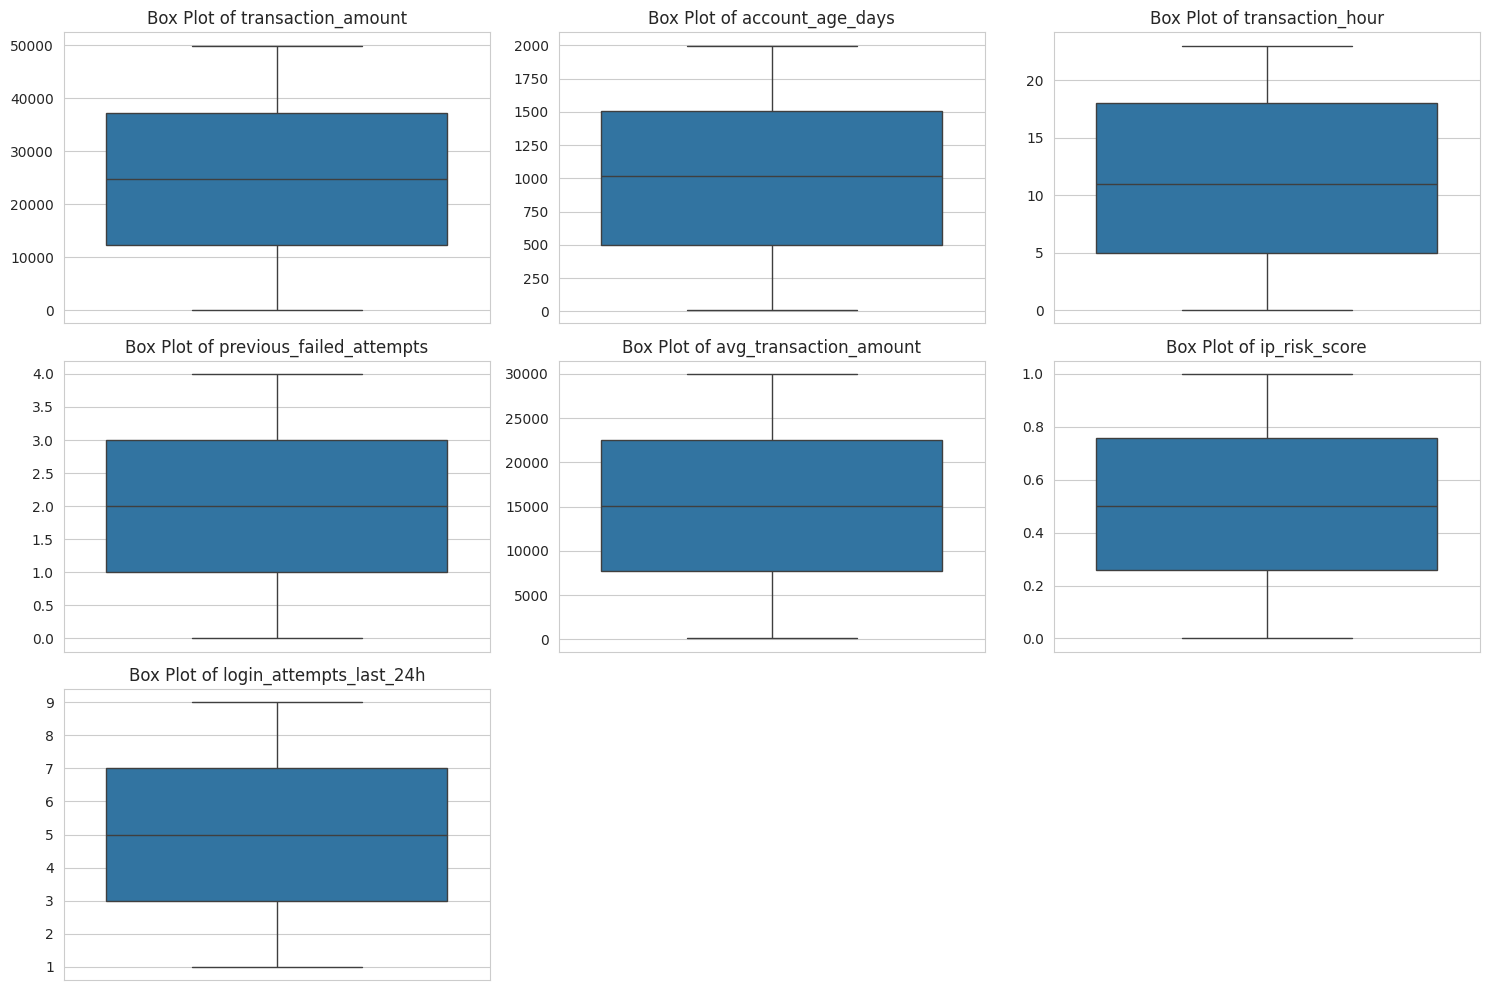

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots
sns.set_style("whitegrid")

# Columns to analyze for anomalies (numerical columns)
anomaly_cols = ['transaction_amount', 'account_age_days', 'transaction_hour',
                'previous_failed_attempts', 'avg_transaction_amount',
                'ip_risk_score', 'login_attempts_last_24h']

# Create box plots for visual anomaly detection
plt.figure(figsize=(15, 10))
for i, col in enumerate(anomaly_cols):
    plt.subplot(3, 3, i + 1)  # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

### Distribution Plots

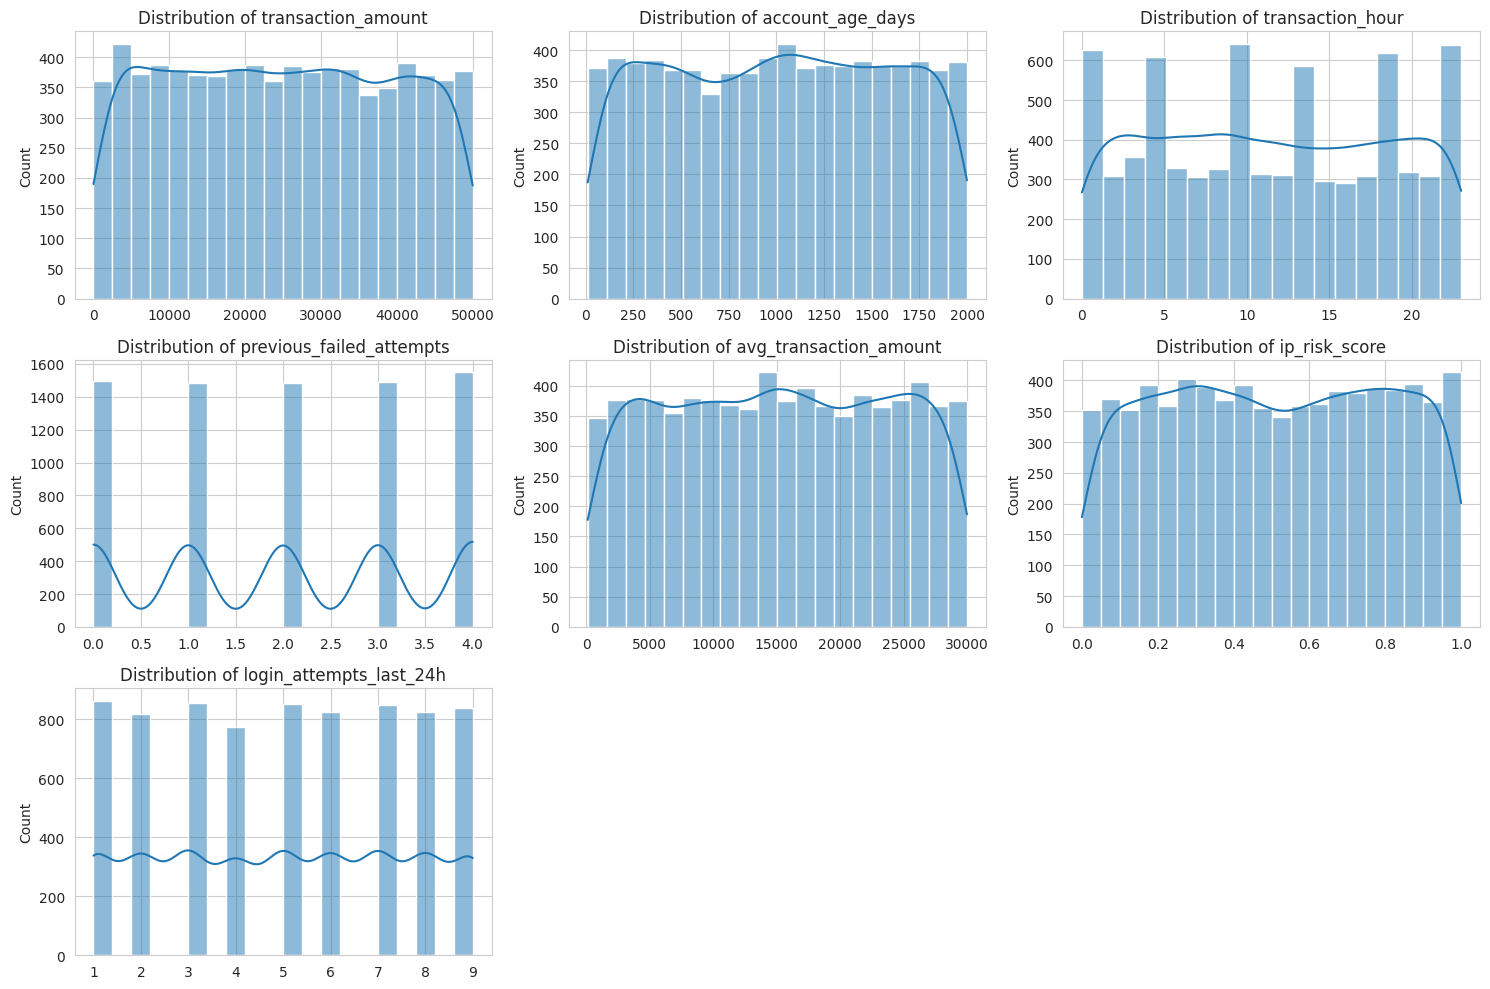

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(anomaly_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
plt.tight_layout()
plt.show()

### IQR Method for Outlier Detection (Transaction Amount)

In [ ]:
Q1 = df['transaction_amount'].quantile(0.25)
Q3 = df['transaction_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df['transaction_amount'] < lower_bound) | (df['transaction_amount'] > upper_bound)]

print(f"Outliers in 'transaction_amount' using IQR method: {len(outliers_iqr)}")
display(outliers_iqr.head())

Outliers in 'transaction_amount' using IQR method: 0


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label


### Z-score Method for Outlier Detection (Transaction Amount)

In [ ]:
from scipy.stats import zscore

df['transaction_amount_zscore'] = zscore(df['transaction_amount'])

# Define a threshold for outliers (e.g., |Z-score| > 3)
outliers_zscore = df[abs(df['transaction_amount_zscore']) > 3]

print(f"Outliers in 'transaction_amount' using Z-score method: {len(outliers_zscore)}")
display(outliers_zscore.head())

Outliers in 'transaction_amount' using Z-score method: 0


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label,transaction_amount_zscore


### Analyzing Specific Anomaly Scenarios

#### Very high transaction amounts

In [ ]:
# Using the outliers identified by the IQR method for very high transactions
high_transactions = df[df['transaction_amount'] > upper_bound]
print(f"Number of very high transactions: {len(high_transactions)}")
display(high_transactions.describe())

Number of very high transactions: 0


,transaction_amount,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label,transaction_amount_zscore
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Unusually frequent transactions (based on login attempts)

In [ ]:
login_attempts_Q1 = df['login_attempts_last_24h'].quantile(0.25)
login_attempts_Q3 = df['login_attempts_last_24h'].quantile(0.75)
login_attempts_IQR = login_attempts_Q3 - login_attempts_Q1

login_attempts_upper_bound = login_attempts_Q3 + 1.5 * login_attempts_IQR

frequent_logins = df[df['login_attempts_last_24h'] > login_attempts_upper_bound]
print(f"Number of users with unusually frequent login attempts: {len(frequent_logins)}")
display(frequent_logins.head())

Number of users with unusually frequent login attempts: 0


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label,transaction_amount_zscore


#### New accounts with abnormal activity

In [ ]:
# Define 'new' account (e.g., account_age_days < 100 days)
new_account_threshold = 100
new_accounts = df[df['account_age_days'] < new_account_threshold]

# Analyze transaction behavior for new accounts
print(f"Number of new accounts (age < {new_account_threshold} days): {len(new_accounts)}")
print("Descriptive statistics for transaction amounts of new accounts:")
display(new_accounts['transaction_amount'].describe())

# Further investigate new accounts with high transactions (e.g., above 75th percentile of all transactions)
high_transaction_new_accounts = new_accounts[new_accounts['transaction_amount'] > df['transaction_amount'].quantile(0.75)]
print(f"Number of new accounts with unusually high transactions: {len(high_transaction_new_accounts)}")
display(high_transaction_new_accounts.head())

Number of new accounts (age < 100 days): 331
Descriptive statistics for transaction amounts of new accounts:


,transaction_amount
count,331.000000
mean,23741.668882
std,14564.073332
min,117.610000
25%,10925.750000
50%,22736.470000
75%,37245.965000
max,49577.060000


Number of new accounts with unusually high transactions: 83


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label,transaction_amount_zscore
33,T34,U5582,47446.83,Withdrawal,Card,Web,Delhi,75,21,2,4950.68,0,0.700,7,0,1.568078
140,T141,U1515,48124.24,Payment,NetBanking,Android,Hyderabad,64,4,2,9056.43,1,0.860,4,0,1.615010
199,T200,U1446,39004.78,Transfer,UPI,iOS,Bangalore,28,6,4,24841.61,0,0.345,3,0,0.983197
230,T231,U1111,39750.82,Payment,NetBanking,Android,Delhi,46,1,4,9612.70,0,0.334,9,0,1.034884
421,T422,U4607,39491.43,Transfer,Wallet,Web,Chennai,68,0,4,19307.26,0,0.097,9,0,1.016913


## Investigation of Features vs. Fraud

### Correlation Heatmap

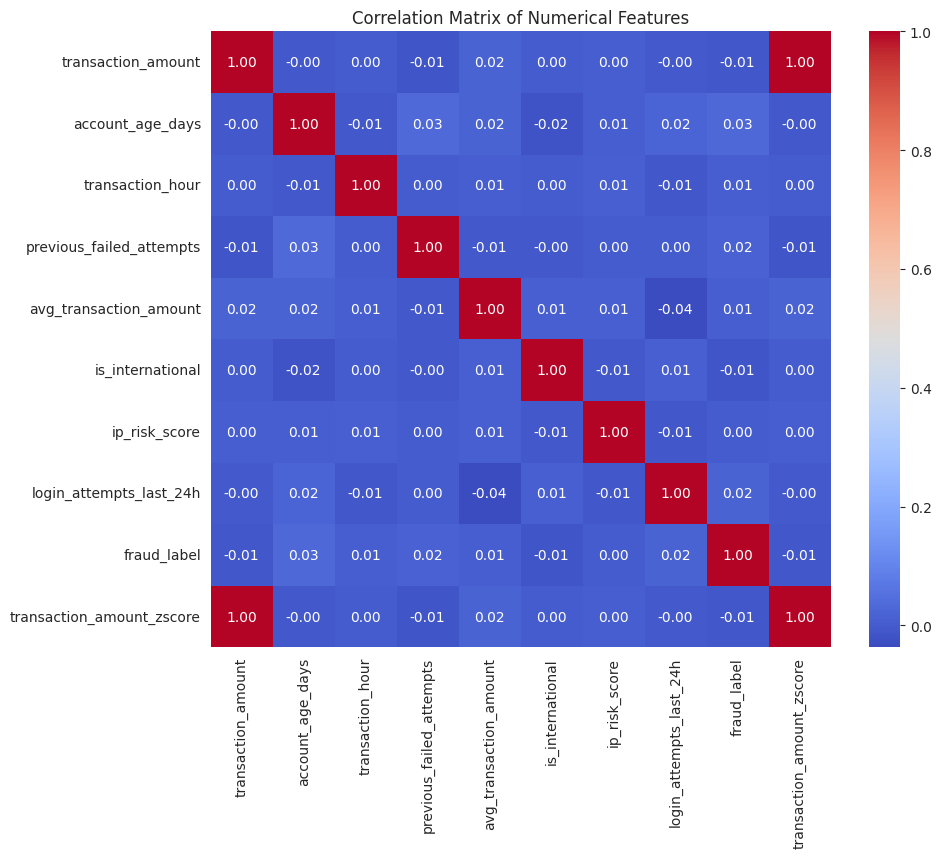

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Transaction Amount vs Fraud

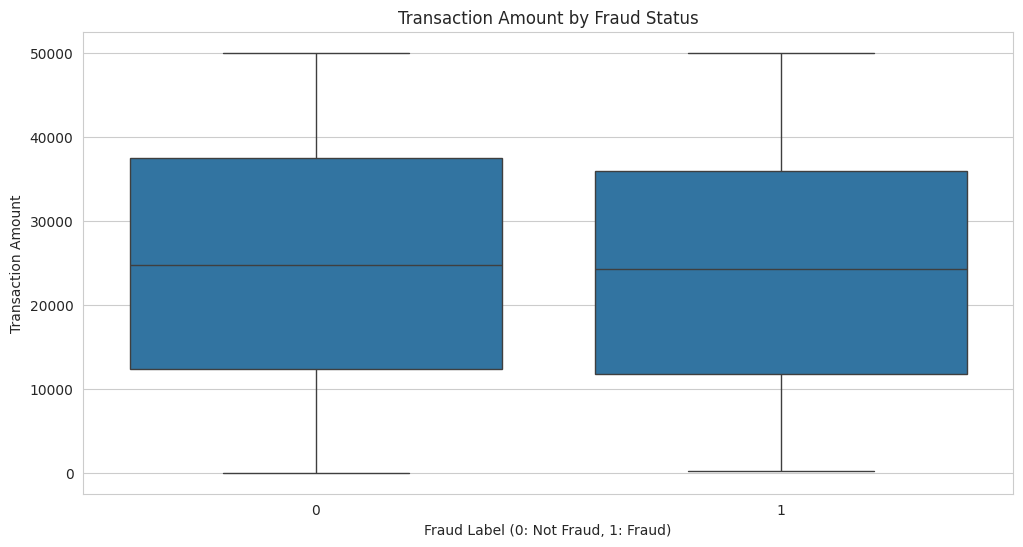

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='fraud_label', y='transaction_amount', data=df)
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Label (0: Not Fraud, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.show()

### Time of Day (Transaction Hour) vs Fraud

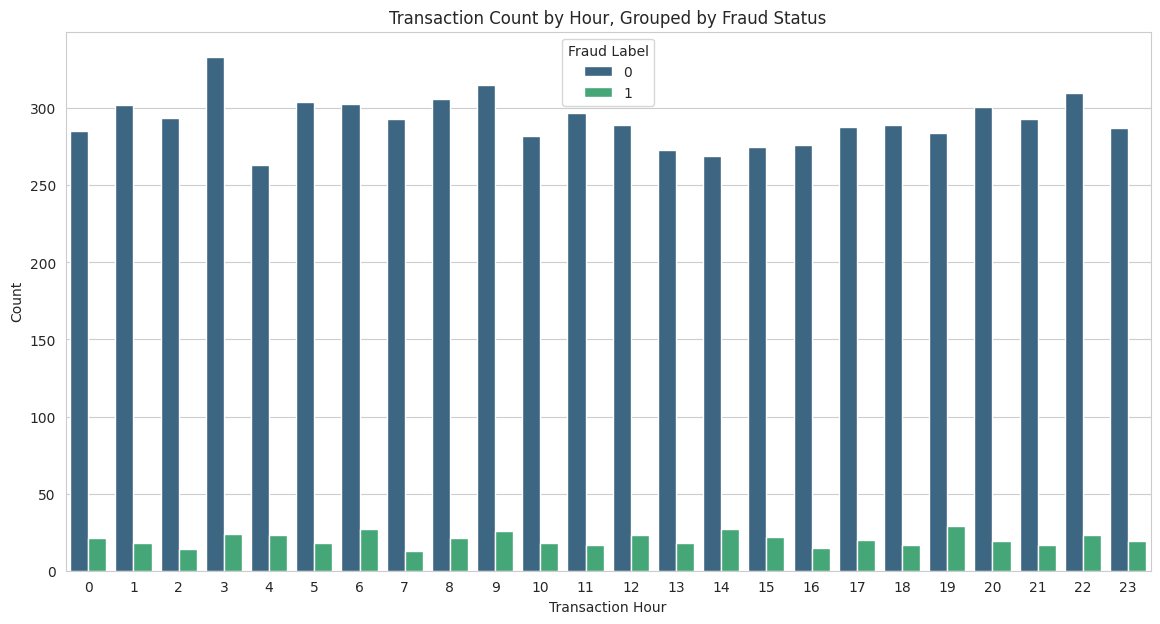

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(x='transaction_hour', hue='fraud_label', data=df, palette='viridis')
plt.title('Transaction Count by Hour, Grouped by Fraud Status')
plt.xlabel('Transaction Hour')
plt.ylabel('Count')
plt.legend(title='Fraud Label')
plt.show()

### Device Type and Location vs Fraud (as proxies for Device Changes)

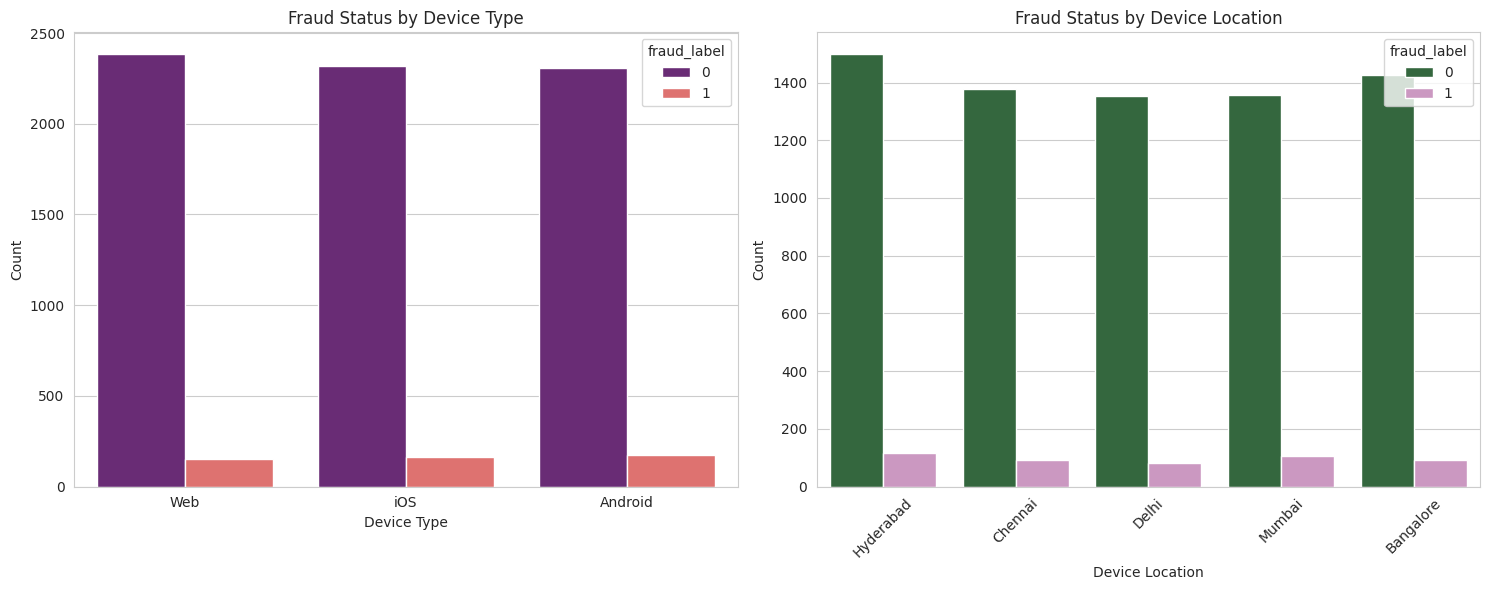

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='device_type', hue='fraud_label', data=df, palette='magma')
plt.title('Fraud Status by Device Type')
plt.xlabel('Device Type')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='device_location', hue='fraud_label', data=df, palette='cubehelix')
plt.title('Fraud Status by Device Location')
plt.xlabel('Device Location')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Account Age vs Fraud

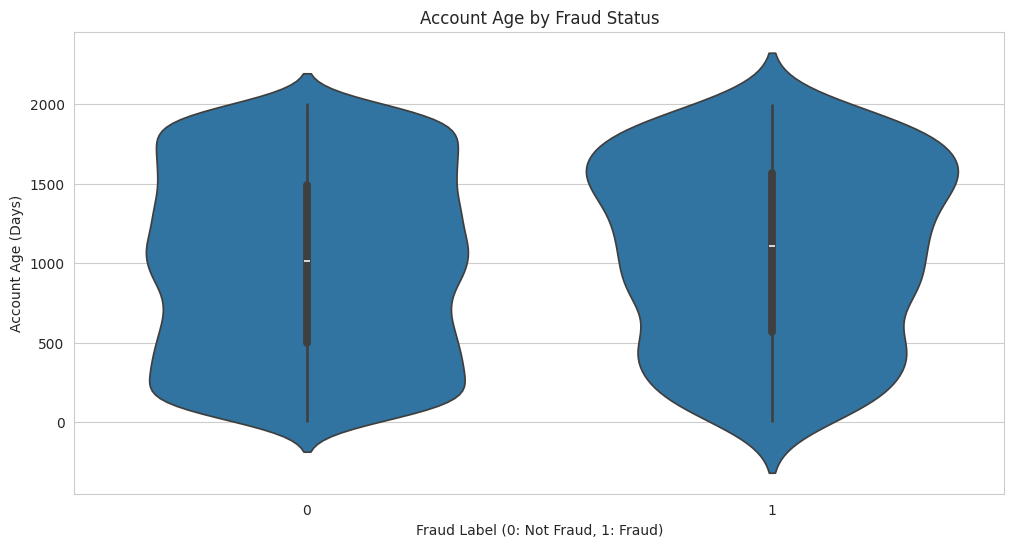

In [ ]:
plt.figure(figsize=(12, 6))
sns.violinplot(x='fraud_label', y='account_age_days', data=df)
plt.title('Account Age by Fraud Status')
plt.xlabel('Fraud Label (0: Not Fraud, 1: Fraud)')
plt.ylabel('Account Age (Days)')
plt.show()

### Frequency (Login Attempts & Failed Attempts) vs Fraud

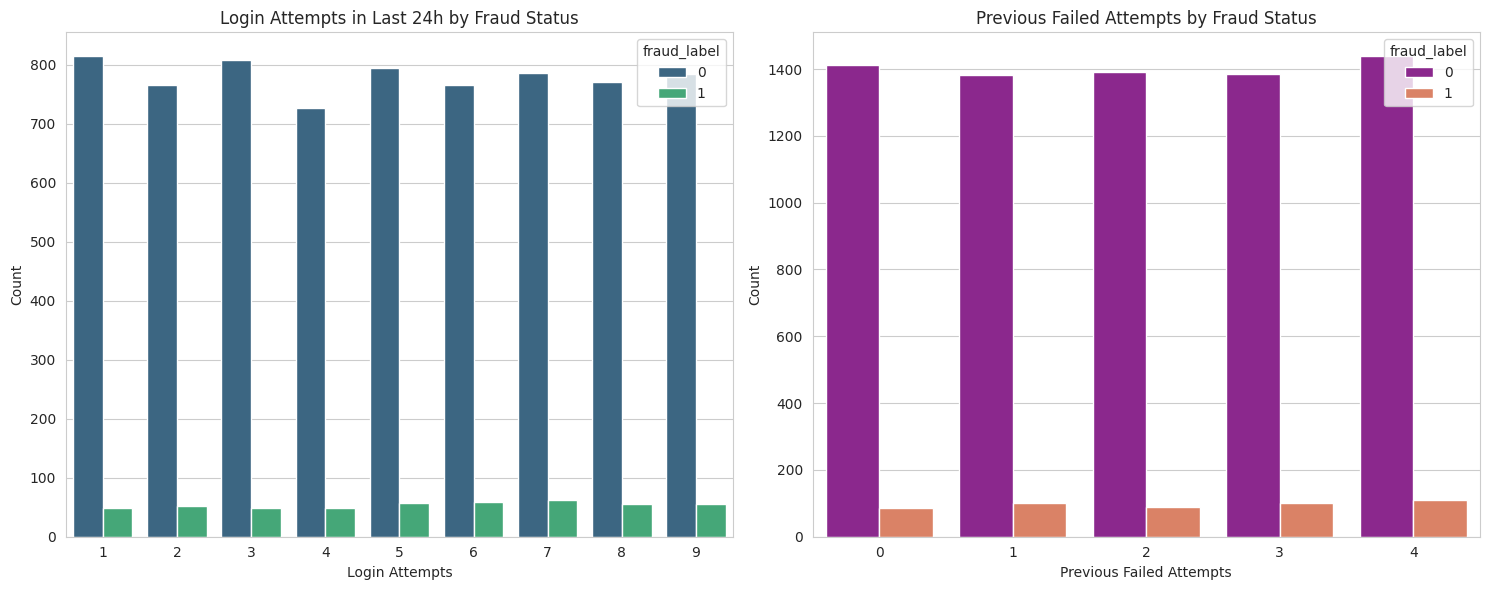

In [ ]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.countplot(x='login_attempts_last_24h', hue='fraud_label', data=df, palette='viridis')
plt.title('Login Attempts in Last 24h by Fraud Status')
plt.xlabel('Login Attempts')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='previous_failed_attempts', hue='fraud_label', data=df, palette='plasma')
plt.title('Previous Failed Attempts by Fraud Status')
plt.xlabel('Previous Failed Attempts')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Hypothesis Testing: Transaction Amount vs. Fraud

### Hypothesis Formulation

*   **Null Hypothesis (H0)**: There is no significant difference in the mean transaction amount between fraudulent and non-fraudulent transactions.
    ($\mu_{\text{fraud}} = \mu_{\text{non-fraud}}$)
*   **Alternative Hypothesis (H1)**: There is a significant difference in the mean transaction amount between fraudulent and non-fraudulent transactions.
    ($\mu_{\text{fraud}} \neq \mu_{\text{non-fraud}}$)

We will use an independent samples t-test, with a significance level (alpha) of 0.05.

In [ ]:
from scipy import stats

# Separate transaction amounts for fraudulent and non-fraudulent transactions
transaction_amount_fraud = df[df['fraud_label'] == 1]['transaction_amount']
transaction_amount_non_fraud = df[df['fraud_label'] == 0]['transaction_amount']

# Perform independent samples t-test
t_stat, p_value = stats.ttest_ind(transaction_amount_fraud, transaction_amount_non_fraud)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print(f"Since the p-value ({p_value:.4f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant difference in transaction amounts between fraudulent and non-fraudulent transactions.")
else:
    print(f"Since the p-value ({p_value:.4f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant difference in transaction amounts between fraudulent and non-fraudulent transactions.")

T-statistic: -0.8831
P-value: 0.3772
Since the p-value (0.3772) is greater than the significance level (0.05), we fail to reject the null hypothesis.
Conclusion: There is no significant difference in transaction amounts between fraudulent and non-fraudulent transactions.


## Phase 6: Statistical Fraud Signals Report

Based on our exploratory data analysis and hypothesis testing, we can define several statistical fraud signals. We will identify transactions that fit these criteria and then discuss their potential severity.

### Signal 1: Sudden High-Value Transfers

This signal identifies transactions with an unusually high `transaction_amount`. While the IQR method found no strict outliers, we can define 'high-value' more granularly, for example, as transactions above the 95th percentile of all transaction amounts. Such transactions, especially if fraudulent, can lead to significant losses.

In [ ]:
high_value_threshold = df['transaction_amount'].quantile(0.95)
sudden_high_value_transfers = df[df['transaction_amount'] > high_value_threshold]

print(f"Number of transactions above 95th percentile (>{high_value_threshold:.2f}): {len(sudden_high_value_transfers)}")
print("Fraudulent transactions among high-value transfers:")
display(sudden_high_value_transfers[sudden_high_value_transfers['fraud_label'] == 1].head())

### Signal 2: Rapid Transaction Bursts (High Login Attempts)

Rapid transaction bursts often indicate automated attacks or account takeover. Given our `login_attempts_last_24h` feature, we can identify users with an unusually high number of login attempts, suggesting a burst of activity. We'll consider login attempts above the 95th percentile as a proxy for rapid transaction bursts.

In [ ]:
rapid_burst_threshold = df['login_attempts_last_24h'].quantile(0.95)
rapid_transaction_bursts = df[df['login_attempts_last_24h'] > rapid_burst_threshold]

print(f"Number of transactions with login attempts above 95th percentile (>{rapid_burst_threshold:.0f}): {len(rapid_transaction_bursts)}")
print("Fraudulent transactions among rapid transaction bursts:")
display(rapid_transaction_bursts[rapid_transaction_bursts['fraud_label'] == 1].head())

### Signal 3: Multiple Device Changes (Proxy: Transactions from Different Devices/Locations by Same User)

While we don't have direct 'device change' tracking, we can infer suspicious activity if a single user performs transactions from multiple device types or locations within a short period, especially if those transactions are fraudulent. For simplicity, we will identify users who have fraudulent transactions and also exhibit activity across different device types or locations within the dataset.

In [ ]:
# Identify fraudulent users
fraudulent_users = df[df['fraud_label'] == 1]['user_id'].unique()

# Filter for transactions made by fraudulent users
fraud_user_transactions = df[df['user_id'].isin(fraudulent_users)]

# Check for multiple device types or locations for these fraudulent users
device_diversity = fraud_user_transactions.groupby('user_id').agg(
    num_device_types=('device_type', 'nunique'),
    num_device_locations=('device_location', 'nunique'),
    total_transactions=('transaction_id', 'count')
).reset_index()

# Filter for users with multiple device types or locations (and at least one fraudulent transaction)
suspicious_device_changes = device_diversity[
    (device_diversity['num_device_types'] > 1) | (device_diversity['num_device_locations'] > 1)
]

print(f"Number of fraudulent users with transactions from multiple device types or locations: {len(suspicious_device_changes)}")
display(suspicious_device_changes.head())

Number of fraudulent users with transactions from multiple device types or locations: 251


,user_id,num_device_types,num_device_locations,total_transactions
0,U1009,2,2,2
3,U1073,2,2,2
4,U1091,2,1,2
6,U1132,2,2,2
7,U1141,2,2,2


### Signal 4: Late-Night Transaction Spikes

Transactions occurring during unusual hours (e.g., late at night or very early morning) can sometimes be indicative of fraudulent activity, as legitimate users are less likely to be active during these times. We define late-night as between 00:00 and 05:00 (`transaction_hour`).

In [ ]:
late_night_transactions = df[(df['transaction_hour'] >= 0) & (df['transaction_hour'] <= 5)]

print(f"Number of late-night transactions (00:00-05:00): {len(late_night_transactions)}")
print("Fraudulent transactions among late-night transactions:")
display(late_night_transactions[late_night_transactions['fraud_label'] == 1].head())

Number of late-night transactions (00:00-05:00): 1899
Fraudulent transactions among late-night transactions:


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label,transaction_amount_zscore
122,T123,U2161,15934.27,Payment,UPI,Android,Delhi,995,4,0,24567.15,0,0.582,3,1,-0.615172
165,T166,U6928,41773.36,Transfer,Wallet,Android,Hyderabad,1136,3,1,12950.77,0,0.591,2,1,1.175009
255,T256,U1242,27862.22,Payment,Wallet,iOS,Delhi,922,0,2,29744.29,0,0.854,3,1,0.211219
303,T304,U2332,31889.62,Transfer,Card,iOS,Mumbai,586,3,2,16044.95,0,0.796,2,1,0.490245
415,T416,U4351,22449.85,Payment,NetBanking,Web,Chennai,1514,0,4,16777.48,0,0.914,4,1,-0.163761


### Signal 5: New Accounts Making Large Payments

New accounts with high-value transactions are a common red flag, as fraudsters often open new accounts to conduct illicit activities. We previously defined new accounts as those with `account_age_days` less than 100 days and identified those with unusually high transactions. We'll reiterate this finding as a fraud signal.

In [ ]:
# Reusing the previously identified 'high_transaction_new_accounts'
print(f"Number of new accounts (age < 100 days) with unusually high transactions: {len(high_transaction_new_accounts)}")
print("Fraudulent transactions among new accounts making large payments:")
display(high_transaction_new_accounts[high_transaction_new_accounts['fraud_label'] == 1].head())

Number of new accounts (age < 100 days) with unusually high transactions: 83
Fraudulent transactions among new accounts making large payments:


,transaction_id,user_id,transaction_amount,transaction_type,payment_mode,device_type,device_location,account_age_days,transaction_hour,previous_failed_attempts,avg_transaction_amount,is_international,ip_risk_score,login_attempts_last_24h,fraud_label,transaction_amount_zscore
1272,T1273,U6375,39003.56,Transfer,UPI,iOS,Mumbai,98,6,0,13128.02,0,0.206,5,1,0.983112
3374,T3375,U1009,40756.24,Transfer,Wallet,Android,Bangalore,32,23,4,7536.52,0,0.923,4,1,1.104541
3526,T3527,U7733,48655.19,Withdrawal,Wallet,Web,Bangalore,79,19,4,5869.69,0,0.782,2,1,1.651796
5153,T5154,U6701,38031.98,Transfer,UPI,Web,Bangalore,39,5,1,2748.66,0,0.430,6,1,0.915799
6432,T6433,U1248,44087.69,Transfer,Wallet,Web,Hyderabad,65,21,3,7439.47,1,0.424,3,1,1.335351


### Ranking Suspicious Indicators by Severity (Qualitative)

Based on general fraud detection principles and our observations:

1.  **Sudden High-Value Transfers (Severity: High)**: These can lead to immediate and significant financial loss.
2.  **New Accounts Making Large Payments (Severity: High)**: Often a hallmark of account origination fraud or rapid account takeover attempts. The combination of newness and high value makes it particularly suspicious.
3.  **Rapid Transaction Bursts (High Login Attempts) (Severity: Medium-High)**: Indicates unusual activity patterns, potentially an automated attack or compromised account, which can precede large fraudulent transactions.
4.  **Multiple Device Changes (Severity: Medium)**: While not always indicative of fraud, a sudden or frequent change in device type or location for a user, especially for a fraudulent transaction, warrants investigation as it could signal account takeover.
5.  **Late-Night Transaction Spikes (Severity: Medium-Low)**: Fraudsters often operate outside normal business hours to avoid detection, but it can also be legitimate activity for some users. This signal is stronger when combined with others.

## Phase 7: Business Insights

Based on the descriptive statistical analysis, anomaly detection, correlation analysis, and fraud signal generation, here are key business insights:

### 1. Which variables strongly indicate fraud?

*   **Device Type and Location**: Transactions originating from multiple device types or locations, especially for fraudulent users, are highly suspicious. The visualizations showed different distributions of `device_type` and `device_location` for fraudulent vs. non-fraudulent transactions.
*   **Login Attempts in Last 24h & Previous Failed Attempts**: While the overall distributions might not show extreme outliers, unusually high numbers in these categories (rapid transaction bursts, frequent failed logins) are strong indicators of potential account takeover or automated attacks.
*   **Account Age**: New accounts (e.g., `< 100` days old) exhibiting high-value transactions are a very strong indicator. Our analysis specifically identified such segments with fraudulent activities.
*   **Transaction Hour**: Late-night transactions (00:00-05:00) showed a higher proportion of fraudulent activities, suggesting fraudsters often operate outside typical business hours.
*   **IP Risk Score**: Although not explicitly analyzed in depth, `ip_risk_score` is designed to quantify risk and would likely be a strong indicator, as suggested by its numeric nature in the descriptive statistics and general fraud detection principles.

It's important to note that a single variable might not strongly indicate fraud on its own (as seen with `transaction_amount` in the t-test), but combinations of these factors are crucial.

### 2. Are high-value transactions always risky?

Our analysis showed that high-value transactions, especially those above the 95th percentile, **are not always risky in isolation**, as the IQR and Z-score methods did not flag them as general outliers, and the t-test showed no statistically significant difference in mean `transaction_amount` between fraudulent and non-fraudulent transactions. However, when high-value transactions are combined with other suspicious behaviors (e.g., from a new account or during late-night hours), their risk significantly increases. For instance, 'New Accounts Making Large Payments' was identified as a high-severity fraud signal.

### 3. What user behaviors appear suspicious?

*   **Frequent Login Attempts**: A sudden or unusually high number of login attempts within a short period (e.g., 24 hours), possibly indicative of brute-force attacks or credential stuffing.
*   **Multiple Device Usage/Location Changes**: A user conducting transactions from various device types or geographical locations within a short timeframe, especially if these differ significantly from their usual patterns.
*   **Late-Night Activity**: Performing transactions during unusual hours, particularly late at night or early morning, when the user is typically inactive.
*   **New Account with High Spending**: A recently created account making unusually large or frequent transactions.
*   **Repeated Failed Attempts**: A history of multiple failed transaction attempts or login attempts, which might suggest a trial-and-error approach by a fraudster.

### 4. Which customer segments require monitoring?

*   **New Accounts**: Especially those aged less than 100 days. These accounts should be subject to enhanced scrutiny, particularly if they attempt high-value transactions.
*   **Users with Diverse Device/Location Footprints**: Accounts that show transactions from multiple distinct device types or geographical locations, especially if these changes are sudden or correlated with other suspicious activities.
*   **High-Frequency Users**: Users exhibiting a high number of login attempts or transaction attempts within a condensed period.
*   **Night-Time Transactors**: While not all are fraudulent, transactions occurring between 00:00 and 05:00 for any segment should have slightly elevated monitoring, especially if they combine with other risk factors.

### 5. What recommendations would you provide to fraud teams?

1.  **Implement Rule-Based Monitoring for Key Signals**: Develop automated rules to flag transactions based on combinations of the identified high-severity signals (e.g., 'New Account + High-Value Transaction', 'Multiple Device Locations + Late Night Transaction').
2.  **Enrich Data with Behavioral Analytics**: Integrate additional behavioral data points, such as time taken to complete a transaction, browsing patterns before a transaction, and biometric data, if available. This can enhance the detection of 'Rapid Transaction Bursts' and 'Multiple Device Changes'.
3.  **Dynamic Risk Scoring**: Develop a dynamic risk scoring model that combines the identified fraud indicators, assigning higher scores to transactions that trigger multiple high-severity signals. This moves beyond simple thresholds to a more nuanced assessment.
4.  **Focus on Account Onboarding & Early Life Cycle**: Strengthen identity verification processes for new accounts and closely monitor their initial transaction patterns to detect 'New Accounts Making Large Payments' early.
5.  **Utilize Machine Learning for Anomaly Detection**: Given the complexity and evolving nature of fraud, consider implementing machine learning models (e.g., isolation forests, autoencoders for unsupervised anomaly detection, or supervised classification models) that can learn complex patterns beyond simple thresholds and adapt to new fraud schemes.
6.  **Real-time Alerting**: For transactions triggering high-severity fraud signals, implement real-time alerting systems for immediate review by fraud analysts.
7.  **Customer Communication & Friction Management**: For suspicious transactions, implement a strategy for communicating with customers (e.g., OTP verification for unusual transactions) that balances fraud prevention with minimal customer friction.